# Importing libraries

In [5]:
from oceanicospy.gis import ShapefileReprojector, reproject_xyz_file, XYZMerger, XYZPointPlotter
import matplotlib.pyplot as plt
import cmocean
import pandas as pd

# Inverting z

In [6]:
def invert_xyz_z_sign(input_path: str, output_path: str, sep: str = r"\s+") -> None:
    """
    Read an .xyz file, invert the sign of the z column, and save a new file.
    
    Parameters
    ----------
    input_path : str
        Path to the input .xyz file.
    output_path : str
        Path to the output .xyz file.
    sep : str, optional
        Column separator. Default assumes whitespace (space or tab).
    """
    # Read XYZ file without header (assumes columns x y z)
    df = pd.read_csv(input_path, sep=sep, header=None, names=["x", "y", "z"])
    
    # Invert the sign of z
    df["z"] = -df["z"]
    
    # Save modified file with same structure
    df.to_csv(output_path, sep=" ", index=False, header=False)
    print(f"File saved: {output_path}")

In [ ]:
invert_xyz_z_sign(r'.../topo_sai_lidarFmenos_AC_MAGNA-ON.xyz')

File saved: /scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/raw/xyz/to_merge/topo_sai_lidarFmenos_AC_MAGNA-ON.xyz


# Reprojecting from .shp to .xyz files

In [ ]:
input_shp = r'.../bat_sai_10m_WGS84.shp'
output_xyz = r'.../bat_sai_10m_MAGNA-ON.xyz'

reproj = ShapefileReprojector(
    input_path=input_shp,    
    z_column="Z", # column name
    source_epsg=None    # use .prj file
)

reproj.reproject_to_epsg(9377) # MAGNA-SIRGAS / Origen-Nacional
reproj.to_xyz(output_xyz)

# Reprojecting from .xyz to .xyz files

In [ ]:
input_xyz = r'.../bat_sai_50m_AC_UTM17N.xyz'
output_xyz = r'...z/bat_sai_50m_AC_MAGNA-ON.xyz'

reproject_xyz_file(
    input_path=input_xyz,
    output_path=output_xyz,
    source_epsg=32617,   # UTM17N
    target_epsg=9377,   # MAGNA-SIRGAS ON  
)

# Merging .xyz files

In [ ]:
# Folder containing the individual XYZ tiles
input_dir = r'.../xyz/to_merge'

# Output merged XYZ path
output_xyz = r'.../topobat_sai_merged_lidar&50m_AC_MAGNA-ON.xyz'

# Manual priority: first = highest priority
manual_priority = [
    "topo_sai_lidarFmenos_AC_MAGNA-ON.xyz",
    "bat_sai_50m_AC_MAGNA-ON.xyz",  
]

merger = XYZMerger(
    input_dir=input_dir,
    crs_epsg="EPSG:9377",          # common CRS of all tiles
    bathy_positive=True,      # Default True if bathymetry uses a positive-downward z value
    manual_priority=manual_priority,
    xy_round_decimals=6,      # xy resolution to generate coverage polygons
)

merger.run_merge(output_xyz)

Merged XYZ exported to: /scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/xyz/topobat_sai_merged_lidar&50m_AC_MAGNA-ON.xyz


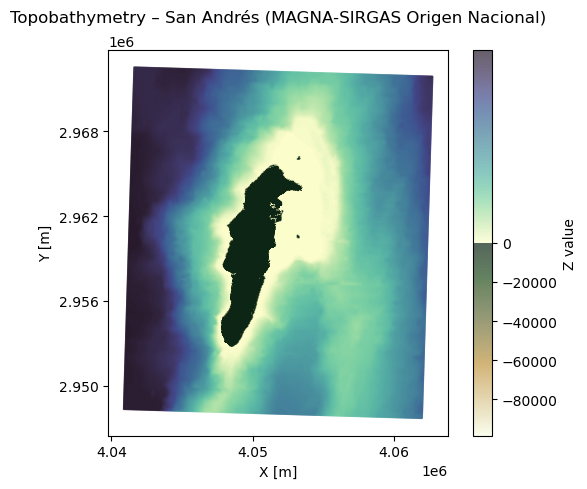

In [ ]:
xyz_path = r'.../topobat_sai_merged_lidar&50m_AC_MAGNA-ON.xyz'
plotter = XYZPointPlotter(default_cmap=cmocean.cm.topo_r)

fig, ax = plotter.plot_xyz_points(
    source=xyz_path,
    title="Topobathymetry – San Andrés (MAGNA-SIRGAS Origen Nacional)"
)
plt.show()